In [ ]:
# %%
# ============================================================================
# A01: Project overview 
# ============================================================================
print("\n" + "="*60)
print("🟢 STARTING A01: Geospatial Identity Analysis")
print("="*60)

def run_a01_analysis():
    """A01: Complete geospatial identity analysis"""
    
    # Load the project boundary
    roi = ee.FeatureCollection("projects/ee-clivedcosta/assets/10lotsmerged")
    
    # Calculate key metrics
    geometry = roi.geometry()
    area_m2 = geometry.area()
    area_ha = area_m2.divide(10000)
    perimeter = geometry.perimeter()
    bounds = geometry.bounds()
    
    # Get centroid
    centroid = geometry.centroid()
    
    # Convert to Python values
    area_ha_val = area_ha.getInfo()
    perimeter_val = perimeter.getInfo()
    centroid_coords = centroid.getInfo()['coordinates']
    bounds_val = bounds.getInfo()
    
    # Create summary dictionary
    summary = {
        'project_name': '10lotsmerged',
        'location': 'From provided asset',
        'total_area_hectares': round(area_ha_val, 2),
        'total_area_sqkm': round(area_ha_val / 100, 2),
        'perimeter_meters': round(perimeter_val, 2),
        'centroid': {
            'longitude': round(centroid_coords[0], 6),
            'latitude': round(centroid_coords[1], 6)
        },
        'centroid_coords': [centroid_coords[1], centroid_coords[0]],  # [lat, lon] format
        'bounding_box': bounds_val,
        'crs': 'EPSG:4326 (WGS84)'
    }
    
    return summary, roi

# Run the analysis
summary_a01, project_roi = run_a01_analysis()

# Display results
print("\n📊 A01 RESULTS: Geospatial Identity")
print("="*40)
for key, value in summary_a01.items():
    if key == 'centroid':
        print(f"📍 Centroid: {value['longitude']}°E, {value['latitude']}°N")
    elif key == 'bounding_box':
        print(f"🗺️  Bounding Box: Available (see map)")
    elif key not in ['centroid_coords', 'bounding_box']:
        print(f"• {key.replace('_', ' ').title()}: {value}")

# %%
# ============================================================================
# VISUALIZE A01 RESULTS ON MAP
# ============================================================================
print("\n🗺️ Creating interactive map...")

# Create map centered on project
Map = geemap.Map(center=summary_a01['centroid_coords'], zoom=12)

# Add basemaps
Map.add_basemap('SATELLITE')
Map.add_basemap('TERRAIN')

# Add project boundary with styling
Map.addLayer(project_roi, 
             {'color': 'blue', 'fillColor': '0000FF20', 'width': 3},
             'Project Boundary (10lotsmerged)')

# FIXED: Add centroid marker without popup (simpler approach)
# Or use text label instead
centroid_lat = summary_a01['centroid']['latitude']
centroid_lon = summary_a01['centroid']['longitude']

# Add a simple point layer for centroid
centroid_point = ee.Geometry.Point([centroid_lon, centroid_lat])
Map.addLayer(centroid_point, 
             {'color': 'red', 'pointSize': 10},
             'Project Centroid')

# Add text label using HTML
label_html = f"""
<div style="position: absolute; 
            top: 10px; 
            left: 10px; 
            background: white; 
            padding: 10px; 
            border-radius: 5px;
            border: 1px solid #ccc;
            font-family: Arial, sans-serif;">
    <b>Project Centroid:</b><br>
    {centroid_lat:.6f}°N, {centroid_lon:.6f}°E
</div>
"""
Map.add_html(label_html)

# Add bounding box
bounds_coords = summary_a01['bounding_box']['coordinates'][0]
bbox = ee.Geometry.Polygon(bounds_coords)
Map.addLayer(bbox, 
             {'color': 'red', 'fillColor': '00000000', 'width': 2},
             'Bounding Box', False)

# Add layer control
Map.add_layer_control()

# Display map
print("✅ Map created. Use layer control (top-right) to toggle layers.")
print(f"📍 Project Centroid: {centroid_lat:.6f}°N, {centroid_lon:.6f}°E")
Map


🟢 STARTING A01: Geospatial Identity Analysis

📊 A01 RESULTS: Geospatial Identity
• Project Name: 10lotsmerged
• Location: From provided asset
• Total Area Hectares: 207.24
• Total Area Sqkm: 2.07
• Perimeter Meters: 93406.3
📍 Centroid: 82.687467°E, 24.378141°N
🗺️  Bounding Box: Available (see map)
• Crs: EPSG:4326 (WGS84)

🗺️ Creating interactive map...
✅ Map created. Use layer control (top-right) to toggle layers.
📍 Project Centroid: 24.378141°N, 82.687467°E


Map(center=[24.37814092235084, 82.68746738922869], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# %%
# ============================================================================
# A02: BIOME & ECOREGION CLASSIFICATION 
# ============================================================================
print("\n" + "="*60)
print("🟢 STARTING A02: Biome & Ecoregion Classification")
print("="*60)

def run_a02_analysis(roi):
    """A02: Identify ecological zone using WWF/FSI biomes"""
    
    print("Loading WWF Ecoregions dataset...")
    
    # Load WWF Ecoregions dataset
    ecoregions = ee.FeatureCollection('RESOLVE/ECOREGIONS/2017')
    
    # Filter to project area
    project_ecoregions = ecoregions.filterBounds(roi)
    
    # Get biome information
    biome_names = project_ecoregions.aggregate_array('BIOME_NAME').distinct()
    realm_names = project_ecoregions.aggregate_array('REALM').distinct()
    eco_names = project_ecoregions.aggregate_array('ECO_NAME').distinct()
    
    # Calculate area of each biome within project
    def calculate_biome_area(feature):
        biome_name = feature.get('BIOME_NAME')
        intersection = feature.geometry().intersection(roi.geometry(), 100)
        area = intersection.area().divide(10000)  # Convert to hectares
        return feature.set({'area_ha': area, 'biome_name': biome_name})
    
    biome_areas = project_ecoregions.map(calculate_biome_area)
    
    # Get summary statistics
    total_biomes = biome_names.size().getInfo()
    total_realms = realm_names.size().getInfo()
    total_ecoregions = eco_names.size().getInfo()
    
    # Get lists
    biome_list = biome_names.getInfo()
    realm_list = realm_names.getInfo()
    eco_list = eco_names.getInfo()
    
    # Create biome area dictionary
    biome_area_dict = {}
    for biome in biome_list:
        # Filter for this biome and sum areas
        biome_features = biome_areas.filter(ee.Filter.eq('BIOME_NAME', biome))
        total_area = biome_features.aggregate_sum('area_ha').getInfo()
        biome_area_dict[biome] = round(total_area, 2) if total_area else 0
    
    return {
        'total_biomes': total_biomes,
        'total_realms': total_realms,
        'total_ecoregions': total_ecoregions,
        'biomes': biome_list,
        'realms': realm_list,
        'ecoregions': eco_list,
        'biome_areas_ha': biome_area_dict,
        'primary_biome': max(biome_area_dict, key=biome_area_dict.get) if biome_area_dict else None
    }, project_ecoregions

# Run A02 analysis
summary_a02, ecoregion_data = run_a02_analysis(project_roi)

# Display results
print("\n🌳 A02 RESULTS: Biome & Ecoregion Classification")
print("="*40)
print(f"• Total Biomes Found: {summary_a02['total_biomes']}")
print(f"• Total Realms: {summary_a02['total_realms']}")
print(f"• Total Ecoregions: {summary_a02['total_ecoregions']}")
print(f"\n📋 PRIMARY BIOME: {summary_a02['primary_biome']}")

print("\n📊 Biome Areas within Project:")
for biome, area in summary_a02['biome_areas_ha'].items():
    print(f"  • {biome}: {area:,.2f} ha")

print("\n🌍 Realms Present:")
for realm in summary_a02['realms']:
    print(f"  • {realm}")

# %%
# ============================================================================
# VISUALIZE A02: BIOME MAP 
# ============================================================================
print("\n🗺️ Creating Biome Visualization Map...")

# Create a new map for biomes
Map_a02 = geemap.Map(center=[summary_a01['centroid']['latitude'], 
                             summary_a01['centroid']['longitude']], 
                     zoom=10)

# Add satellite basemap
Map_a02.add_basemap('SATELLITE')

# Add project boundary
Map_a02.addLayer(project_roi, 
                 {'color': 'white', 'width': 3},
                 'Project Boundary')

# CORRECTED: Add biome/ecoregion layers directly without .style()
# We'll visualize biomes by their BIOME_NUM with a color palette
Map_a02.addLayer(ecoregion_data, 
                 {'color': 'green', 'fillColor': '00000000', 'width': 1},
                 'Ecoregion Boundaries (Outline Only)', True)

# Alternative: Create a colored biome map by converting to image
# First, create a feature collection with biome numbers
biome_fc = ecoregion_data.select(['BIOME_NUM', 'BIOME_NAME'])

# Convert to an image using .reduceToImage()
biome_image = biome_fc.reduceToImage(
    properties=['BIOME_NUM'],
    reducer=ee.Reducer.first()
).clip(roi)

# Define a color palette for biomes
# Using a simple palette - you can customize this
biome_palette = [
    '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99',
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
    '#ffff99', '#b15928'
]

# Add the colored biome map
Map_a02.addLayer(biome_image, 
                 {'min': 1, 'max': 12, 'palette': biome_palette},
                 'Biome Classification (Colored)', True)

# Add a legend for biomes
# First, let's create a biome legend dictionary
if summary_a02['biomes']:
    legend_dict = {}
    for i, biome in enumerate(summary_a02['biomes'][:len(biome_palette)]):
        legend_dict[biome] = biome_palette[i]
    
    Map_a02.add_legend(
        title="Biome Types",
        legend_dict=legend_dict,
        position='bottomright'
    )

print("✅ Biome map created.")
print("   Green outlines: Ecoregion boundaries")
print("   Colored areas: Biome classification")
Map_a02


🟢 STARTING A02: Biome & Ecoregion Classification
Loading WWF Ecoregions dataset...

🌳 A02 RESULTS: Biome & Ecoregion Classification
• Total Biomes Found: 1
• Total Realms: 1
• Total Ecoregions: 2

📋 PRIMARY BIOME: Tropical & Subtropical Dry Broadleaf Forests

📊 Biome Areas within Project:
  • Tropical & Subtropical Dry Broadleaf Forests: 206.43 ha

🌍 Realms Present:
  • Indomalayan

🗺️ Creating Biome Visualization Map...


✅ Biome map created.
   Green outlines: Ecoregion boundaries
   Colored areas: Biome classification


Map(center=[24.378141, 82.687467], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…


🟢 A03: Enhanced Climatic Suitability Analysis

Running enhanced climate analysis...
Loading climate data (CHIRPS & ERA5) for comprehensive analysis...
  🌧️ Creating Precipitation Map...


  🌡️ Creating Temperature Map...


  🗺️ Creating Climate Zone Map...


  🌳 Creating Suitability Map...


  🗺️ Finalizing Master Map...

🌤️ A03 RESULTS: Comprehensive Climatic Analysis

📍 CLIMATE SUMMARY FOR PROJECT AREA:
----------------------------------------
• Mean Annual Precipitation: 1085.65 mm
• Mean Annual Temperature: 24.61 °C
• Climate Zone: Tropical Rainforest (Af)
• Afforestation Suitability: Suitable
• Data Period: 2019-01-01 to 2023-12-31

📈 ANNUAL PRECIPITATION TREND (2019-2023):
----------------------------------------
  • 2019: 1184 mm
  • 2020: 1237 mm
  • 2021: 1252 mm
  • 2022: 1030 mm
  • 2023: 724 mm

📊 Precipitation Trend: -460 mm (-38.8%) over 5 years

💡 INTERPRETATION:
----------------------------------------
✅ EXCELLENT conditions for tree growth!
   • Temperature range supports most tree species
   • Adequate rainfall for healthy growth
   • Proceed with diverse species selection

🗺️ A03 MASTER MAP: Switchable Climate Layers

🎨 AVAILABLE LAYERS (toggle using control panel):
--------------------------------------------------
1. 🌧️ Precipitation - Annual rainfall 

Map(center=[24.37814092235084, 82.68746738922869], controls=(WidgetControl(options=['position', 'transparent_b…


📍 INDIVIDUAL CLIMATE MAPS



Select tabs below to view individual climate maps:



📊 CLIMATE SUITABILITY CHART


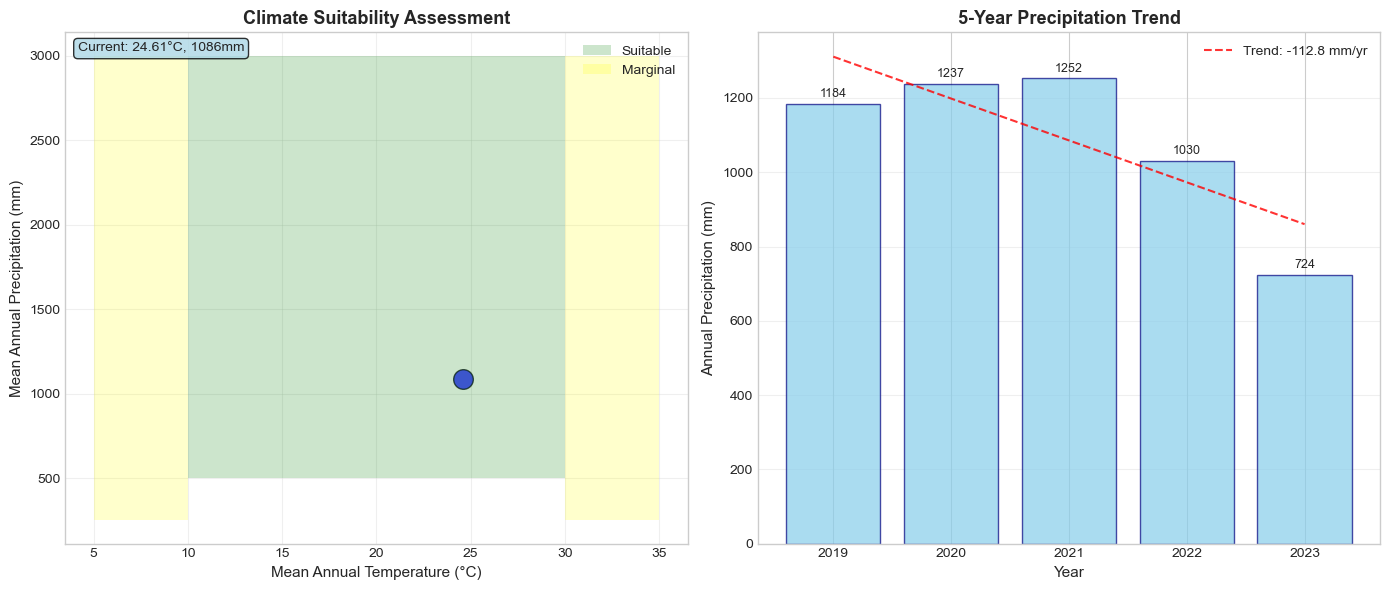


📋 RECOMMENDATIONS BASED ON CLIMATE:
----------------------------------------
✅ RECOMMENDED SPECIES:
   • Fast-growing native trees
   • Fruit and nut trees for agroforestry
   • Diverse mixed-species planting

✅ MANAGEMENT PRACTICES:
   • Natural regeneration encouraged
   • Minimal irrigation needed
   • Year-round planting possible

✅ A03 COMPLETE - Master map with switchable layers ready!

💾 EXPORTING CLIMATE ANALYSIS RESULTS
✅ Climate results saved to: exports/A03_climate_results.json
✅ Climate report saved to: exports/A03_climate_report.txt

🎯 NEXT STEPS FOR CLIMATE ANALYSIS:
----------------------------------------
1. Review suitability map for microclimate variations
2. Select tree species based on climate zone
3. Plan planting schedule around rainy seasons
4. Monitor climate conditions during implementation

✨ A03: Comprehensive climate analysis complete!


In [34]:
# %%
# ============================================================================
# A03: ENHANCED CLIMATIC SUITABILITY ANALYSIS WITH MASTER MAP
# ============================================================================
print("\n" + "="*60)
print("🟢 A03: Enhanced Climatic Suitability Analysis")
print("="*60)

def run_enhanced_a03_analysis(roi):
    """Enhanced A03: Assess climate conditions with multiple visualization layers"""
    
    print("Loading climate data (CHIRPS & ERA5) for comprehensive analysis...")
    
    # Get ROI centroid for map center
    centroid = roi.geometry().centroid().getInfo()['coordinates']
    
    # Initialize master map
    master_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=10)
    master_map.add_basemap('SATELLITE')
    
    # 1. PRECIPITATION DATA (CHIRPS)
    chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
    
    # Get last 5 years of data
    start_date = '2019-01-01'
    end_date = '2023-12-31'
    
    # Filter precipitation data
    precipitation = chirps.filterDate(start_date, end_date) \
                          .filterBounds(roi) \
                          .select('precipitation')
    
    # Calculate annual precipitation
    def calculate_annual_precip(year):
        yearly = chirps.filterDate(f'{year}-01-01', f'{year}-12-31') \
                      .filterBounds(roi) \
                      .select('precipitation')
        total = yearly.sum()
        mean = total.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=5000,
            maxPixels=1e9
        ).get('precipitation')
        return mean
    
    # Get precipitation for last 5 years
    years = [2019, 2020, 2021, 2022, 2023]
    annual_precip = {}
    for year in years:
        precip = calculate_annual_precip(year)
        annual_precip[year] = precip.getInfo() if precip else None
    
    # Calculate mean annual precipitation
    valid_precip = [p for p in annual_precip.values() if p is not None]
    mean_annual_precip = sum(valid_precip) / len(valid_precip) if valid_precip else None
    
    # Create precipitation map
    print("  🌧️ Creating Precipitation Map...")
    mean_precip = precipitation.mean().clip(roi)
    
    # Create individual precipitation map
    precip_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=10)
    precip_map.add_basemap('SATELLITE')
    
    precip_vis = {
        'min': 0,
        'max': 3000,
        'palette': ['white', 'lightblue', 'blue', 'darkblue', 'navy']
    }
    
    precip_map.addLayer(mean_precip, precip_vis, 'Mean Annual Precipitation (mm)')
    precip_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
    precip_map.add_colorbar(precip_vis, label="Precipitation (mm)", orientation="vertical")
    
    # Add precipitation layer to master map
    master_map.addLayer(mean_precip, precip_vis, 'Precipitation', False)
    
    # 2. TEMPERATURE DATA (ERA5)
    print("  🌡️ Creating Temperature Map...")
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY')
    
    # Get temperature data
    temperature = era5.filterDate(start_date, end_date) \
                     .filterBounds(roi) \
                     .select('temperature_2m')
    
    # Calculate mean temperature and convert to Celsius
    temp_mean = temperature.mean().subtract(273.15).clip(roi)  # Convert K to °C
    
    # Create individual temperature map
    temp_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=10)
    temp_map.add_basemap('SATELLITE')
    
    temp_vis = {
        'min': -10,
        'max': 40,
        'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red', 'darkred']
    }
    
    temp_map.addLayer(temp_mean, temp_vis, 'Mean Annual Temperature (°C)')
    temp_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
    temp_map.add_colorbar(temp_vis, label="Temperature (°C)", orientation="vertical")
    
    # Add temperature layer to master map
    master_map.addLayer(temp_mean, temp_vis, 'Temperature', False)
    
    # Get temperature statistics for ROI
    mean_temp_stats = temp_mean.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi.geometry(),
        scale=5000,
        maxPixels=1e9
    ).get('temperature_2m')
    
    mean_temp_c = mean_temp_stats.getInfo() if mean_temp_stats else None
    
    # 3. CLIMATE ZONE CLASSIFICATION
    print("  🗺️ Creating Climate Zone Map...")
    
    # Create simplified climate zone classification
    # Based on temperature and precipitation
    def classify_climate(temp_img, precip_img):
        """Classify climate zones based on temperature and precipitation"""
        
        # Temperature classes
        temp_tropical = temp_img.gt(18)  # Tropical: >18°C
        temp_temperate = temp_img.gte(0).And(temp_img.lte(18))  # Temperate: 0-18°C
        temp_cold = temp_img.lt(0)  # Cold: <0°C
        
        # Precipitation classes
        precip_high = precip_img.gt(1000)  # High: >1000mm
        precip_medium = precip_img.gt(500).And(precip_img.lte(1000))  # Medium: 500-1000mm
        precip_low = precip_img.lte(500)  # Low: <=500mm
        
        # Create climate zones (0-7)
        climate_zone = ee.Image(0)
        
        # Tropical zones (1-3)
        climate_zone = climate_zone.where(temp_tropical.And(precip_high), 1)    # Tropical Rainforest
        climate_zone = climate_zone.where(temp_tropical.And(precip_medium), 2)  # Tropical Monsoon
        climate_zone = climate_zone.where(temp_tropical.And(precip_low), 3)     # Tropical Savannah
        
        # Temperate zones (4-6)
        climate_zone = climate_zone.where(temp_temperate.And(precip_high), 4)   # Temperate Humid
        climate_zone = climate_zone.where(temp_temperate.And(precip_medium), 5) # Temperate
        climate_zone = climate_zone.where(temp_temperate.And(precip_low), 6)    # Temperate Dry
        
        # Cold zones (7)
        climate_zone = climate_zone.where(temp_cold, 7)                         # Cold Climate
        
        return climate_zone.rename('climate_zone')
    
    # Create climate zone map
    climate_zone_img = classify_climate(temp_mean, mean_precip).clip(roi)
    
    # Create individual climate zone map
    climate_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=10)
    climate_map.add_basemap('SATELLITE')
    
    # Color palette for climate zones
    climate_palette = [
        '#006400',  # 1: Tropical Rainforest - Dark Green
        '#32CD32',  # 2: Tropical Monsoon - Lime Green
        '#FFD700',  # 3: Tropical Savannah - Gold
        '#1E90FF',  # 4: Temperate Humid - Dodger Blue
        '#87CEEB',  # 5: Temperate - Sky Blue
        '#FFA500',  # 6: Temperate Dry - Orange
        '#ADD8E6',  # 7: Cold Climate - Light Blue
    ]
    
    climate_vis = {
        'min': 1,
        'max': 7,
        'palette': climate_palette
    }
    
    climate_map.addLayer(climate_zone_img, climate_vis, 'Climate Zones')
    climate_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
    
    # Add custom legend for climate zones
    climate_legend_dict = {
        'Tropical Rainforest': '#006400',
        'Tropical Monsoon': '#32CD32',
        'Tropical Savannah': '#FFD700',
        'Temperate Humid': '#1E90FF',
        'Temperate': '#87CEEB',
        'Temperate Dry': '#FFA500',
        'Cold Climate': '#ADD8E6'
    }
    
    climate_map.add_legend(legend_title="Climate Zones", legend_dict=climate_legend_dict)
    
    # Add climate zone layer to master map
    master_map.addLayer(climate_zone_img, climate_vis, 'Climate Zones', False)
    
    # 4. SUITABILITY MAP
    print("  🌳 Creating Suitability Map...")
    
    # Create suitability classification based on temperature and precipitation
    def classify_suitability(temp_img, precip_img):
        """Classify suitability for afforestation"""
        
        # Optimal conditions: Temperature 10-30°C, Precipitation >500mm
        temp_optimal = temp_img.gte(10).And(temp_img.lte(30))
        precip_optimal = precip_img.gt(500)
        
        # Marginal conditions: Temperature 5-10°C or 30-35°C, Precipitation 250-500mm
        temp_marginal = temp_img.gte(5).And(temp_img.lt(10)).Or(temp_img.gt(30).And(temp_img.lte(35)))
        precip_marginal = precip_img.gte(250).And(precip_img.lte(500))
        
        # Unsuitable conditions: Temperature <5°C or >35°C, Precipitation <250mm
        temp_unsuitable = temp_img.lt(5).Or(temp_img.gt(35))
        precip_unsuitable = precip_img.lt(250)
        
        # Create suitability classes
        suitability = ee.Image(0)  # 0 = No data
        
        # Suitable (3)
        suitability = suitability.where(temp_optimal.And(precip_optimal), 3)
        
        # Marginal (2)
        suitability = suitability.where(temp_marginal.And(precip_marginal), 2)
        suitability = suitability.where(temp_optimal.And(precip_marginal), 2)
        suitability = suitability.where(temp_marginal.And(precip_optimal), 2)
        
        # Unsuitable (1)
        suitability = suitability.where(temp_unsuitable.Or(precip_unsuitable), 1)
        
        return suitability.rename('suitability')
    
    # Create suitability map
    suitability_img = classify_suitability(temp_mean, mean_precip).clip(roi)
    
    # Create individual suitability map
    suitability_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=10)
    suitability_map.add_basemap('SATELLITE')
    
    suitability_palette = ['#FF0000', '#FFFF00', '#00FF00']  # Red, Yellow, Green
    suitability_vis = {
        'min': 1,
        'max': 3,
        'palette': suitability_palette
    }
    
    suitability_map.addLayer(suitability_img, suitability_vis, 'Afforestation Suitability')
    suitability_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
    
    # Add suitability legend
    suitability_legend_dict = {
        'Unsuitable': '#FF0000',
        'Marginal': '#FFFF00',
        'Suitable': '#00FF00'
    }
    
    suitability_map.add_legend(legend_title="Suitability", legend_dict=suitability_legend_dict)
    
    # Add suitability layer to master map
    master_map.addLayer(suitability_img, suitability_vis, 'Suitability', False)
    
    # 5. FINALIZE MASTER MAP
    print("  🗺️ Finalizing Master Map...")
    
    # Add project boundary to master map
    master_map.addLayer(roi, {'color': 'cyan', 'width': 3, 'fillColor': '00000000'}, 'Project Boundary')
    
    # Add layer control
    master_map.add_layer_control()
    
    # Determine overall climate zone for ROI
    climate_zone = "Unknown"
    if mean_temp_c and mean_annual_precip:
        if mean_temp_c > 18:
            if mean_annual_precip > 1000:
                climate_zone = "Tropical Rainforest (Af)"
            elif mean_annual_precip > 500:
                climate_zone = "Tropical Monsoon (Am)"
            else:
                climate_zone = "Tropical Savannah (Aw)"
        elif mean_temp_c > 0:
            if mean_annual_precip > 1000:
                climate_zone = "Temperate Humid (Cfa)"
            elif mean_annual_precip > 500:
                climate_zone = "Temperate (Cwb)"
            else:
                climate_zone = "Temperate Dry (Csa)"
        else:
            climate_zone = "Cold Climate"
    
    # Determine overall suitability
    if mean_temp_c and mean_annual_precip:
        if 10 <= mean_temp_c <= 30 and mean_annual_precip > 500:
            overall_suitability = "Suitable"
        elif 5 <= mean_temp_c <= 35 and mean_annual_precip > 250:
            overall_suitability = "Marginal"
        else:
            overall_suitability = "Unsuitable"
    else:
        overall_suitability = "Unknown"
    
    results = {
        'mean_annual_precipitation_mm': round(mean_annual_precip, 2) if mean_annual_precip else None,
        'mean_annual_temperature_c': round(mean_temp_c, 2) if mean_temp_c else None,
        'climate_zone': climate_zone,
        'suitability': overall_suitability,
        'annual_precipitation_mm': annual_precip,
        'data_period': f"{start_date} to {end_date}",
        'maps': {
            'precipitation': precip_map,
            'temperature': temp_map,
            'climate_zones': climate_map,
            'suitability': suitability_map,
            'master': master_map
        }
    }
    
    return results

# Run enhanced A03 analysis
print("\nRunning enhanced climate analysis...")
results_a03 = run_enhanced_a03_analysis(project_roi)

# %%
# ============================================================================
# DISPLAY A03 RESULTS
# ============================================================================
print("\n" + "="*60)
print("🌤️ A03 RESULTS: Comprehensive Climatic Analysis")
print("="*60)

print(f"\n📍 CLIMATE SUMMARY FOR PROJECT AREA:")
print("-" * 40)
print(f"• Mean Annual Precipitation: {results_a03['mean_annual_precipitation_mm']} mm")
print(f"• Mean Annual Temperature: {results_a03['mean_annual_temperature_c']} °C")
print(f"• Climate Zone: {results_a03['climate_zone']}")
print(f"• Afforestation Suitability: {results_a03['suitability']}")
print(f"• Data Period: {results_a03['data_period']}")

print("\n📈 ANNUAL PRECIPITATION TREND (2019-2023):")
print("-" * 40)
for year, precip in results_a03['annual_precipitation_mm'].items():
    if precip:
        print(f"  • {year}: {precip:.0f} mm")

# Calculate trend
if results_a03['annual_precipitation_mm']:
    precip_values = [p for p in results_a03['annual_precipitation_mm'].values() if p]
    if len(precip_values) > 1:
        trend = precip_values[-1] - precip_values[0]
        trend_percent = (trend / precip_values[0]) * 100 if precip_values[0] != 0 else 0
        print(f"\n📊 Precipitation Trend: {trend:+.0f} mm ({trend_percent:+.1f}%) over 5 years")

print("\n💡 INTERPRETATION:")
print("-" * 40)
if results_a03['suitability'] == "Suitable":
    print("✅ EXCELLENT conditions for tree growth!")
    print("   • Temperature range supports most tree species")
    print("   • Adequate rainfall for healthy growth")
    print("   • Proceed with diverse species selection")
elif results_a03['suitability'] == "Marginal":
    print("⚠️ MODERATE conditions - careful planning needed")
    print("   • Consider drought-tolerant species")
    print("   • May require irrigation in dry seasons")
    print("   • Focus on native, resilient species")
else:
    print("❌ CHALLENGING conditions for afforestation")
    print("   • Consider alternative land uses")
    print("   • If proceeding, select highly resilient species")
    print("   • Extensive soil and water management needed")

# %%
# ============================================================================
# DISPLAY MASTER MAP
# ============================================================================
print("\n" + "="*60)
print("🗺️ A03 MASTER MAP: Switchable Climate Layers")
print("="*60)

print("\n🎨 AVAILABLE LAYERS (toggle using control panel):")
print("-" * 50)
print("1. 🌧️ Precipitation - Annual rainfall distribution (blue scale)")
print("2. 🌡️ Temperature - Mean annual temperature (thermal scale)")
print("3. 🗺️ Climate Zones - Koppen-Geiger climate classification")
print("4. 🌳 Suitability - Afforestation suitability assessment")
print("5. 📍 Project Boundary - Project area outline")

print("\n💡 HOW TO USE:")
print("-" * 30)
print("• Click layers on/off in control panel (top-right)")
print("• Precipitation shows rainfall amounts (blue = more rain)")
print("• Temperature shows thermal zones (red = warmer)")
print("• Climate zones show regional climate classification")
print("• Suitability: Green=Good, Yellow=Marginal, Red=Poor")

# Display the master map
display(results_a03['maps']['master'])

# %%
# ============================================================================
# TABBED MAP INTERFACE
# ============================================================================
print("\n" + "="*60)
print("📍 INDIVIDUAL CLIMATE MAPS")
print("="*60)

import ipywidgets as widgets
from IPython.display import display

# Create tabs for individual maps
tab_names = ['Precipitation', 'Temperature', 'Climate Zones', 'Suitability']
tabs = widgets.Tab()

tab_contents = []
for name in tab_names:
    output = widgets.Output()
    with output:
        map_key = name.lower().replace(' ', '_')
        if map_key in results_a03['maps']:
            print(f"\n🗺️ {name.upper()} MAP")
            print("-" * 30)
            if map_key == 'climate_zones':
                print("Color Legend:")
                print("• Dark Green: Tropical Rainforest")
                print("• Lime Green: Tropical Monsoon")
                print("• Gold: Tropical Savannah")
                print("• Blue: Temperate Humid")
                print("• Sky Blue: Temperate")
                print("• Orange: Temperate Dry")
                print("• Light Blue: Cold Climate")
            elif map_key == 'suitability':
                print("Color Legend:")
                print("• 🟢 Green: Suitable for afforestation")
                print("• 🟡 Yellow: Marginal conditions")
                print("• 🔴 Red: Unsuitable")
            display(results_a03['maps'][map_key])
        else:
            print(f"⚠️ {name} map not available")
    tab_contents.append(output)

tabs.children = tab_contents
for i, name in enumerate(tab_names):
    tabs.set_title(i, name)

print("\nSelect tabs below to view individual climate maps:")
display(tabs)

# %%
# ============================================================================
# CLIMATE SUITABILITY CHART
# ============================================================================
print("\n" + "="*60)
print("📊 CLIMATE SUITABILITY CHART")
print("="*60)

import matplotlib.pyplot as plt
import numpy as np

# Create a simple suitability chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Temperature vs Precipitation scatter
if results_a03['mean_annual_temperature_c'] and results_a03['mean_annual_precipitation_mm']:
    temp = results_a03['mean_annual_temperature_c']
    precip = results_a03['mean_annual_precipitation_mm']
    
    # Plot point
    ax1.scatter(temp, precip, s=200, c='blue', alpha=0.7, edgecolors='black')
    
    # Add suitability zones
    # Suitable zone
    suitable_temp = np.array([10, 30, 30, 10, 10])
    suitable_precip = np.array([500, 500, 3000, 3000, 500])
    ax1.fill(suitable_temp, suitable_precip, 'green', alpha=0.2, label='Suitable')
    
    # Marginal zone
    marginal_temp1 = np.array([5, 10, 10, 5, 5])
    marginal_precip1 = np.array([250, 250, 3000, 3000, 250])
    marginal_temp2 = np.array([30, 35, 35, 30, 30])
    marginal_precip2 = np.array([250, 250, 3000, 3000, 250])
    ax1.fill(marginal_temp1, marginal_precip1, 'yellow', alpha=0.2, label='Marginal')
    ax1.fill(marginal_temp2, marginal_precip2, 'yellow', alpha=0.2)
    
    ax1.set_xlabel('Mean Annual Temperature (°C)', fontsize=11)
    ax1.set_ylabel('Mean Annual Precipitation (mm)', fontsize=11)
    ax1.set_title('Climate Suitability Assessment', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    ax1.text(0.02, 0.98, f'Current: {temp}°C, {precip:.0f}mm', 
             transform=ax1.transAxes, fontsize=10, 
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
else:
    ax1.text(0.5, 0.5, 'No climate data available', 
             horizontalalignment='center', verticalalignment='center',
             transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Climate Suitability Assessment', fontsize=13, fontweight='bold')

# Chart 2: Annual precipitation trend
if results_a03['annual_precipitation_mm']:
    years = list(results_a03['annual_precipitation_mm'].keys())
    precip_values = list(results_a03['annual_precipitation_mm'].values())
    
    # Filter out None values
    valid_data = [(year, precip) for year, precip in zip(years, precip_values) if precip is not None]
    if valid_data:
        years_valid, precip_valid = zip(*valid_data)
        
        bars = ax2.bar(years_valid, precip_valid, color='skyblue', edgecolor='navy', alpha=0.7)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=9)
        
        ax2.set_xlabel('Year', fontsize=11)
        ax2.set_ylabel('Annual Precipitation (mm)', fontsize=11)
        ax2.set_title('5-Year Precipitation Trend', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add trend line
        if len(precip_valid) > 1:
            x_numeric = np.arange(len(precip_valid))
            z = np.polyfit(x_numeric, precip_valid, 1)
            p = np.poly1d(z)
            ax2.plot(years_valid, p(x_numeric), "r--", alpha=0.8, label=f'Trend: {z[0]:+.1f} mm/yr')
            ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'No precipitation data available', 
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax2.transAxes, fontsize=12)
        ax2.set_title('5-Year Precipitation Trend', fontsize=13, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No precipitation data available', 
             horizontalalignment='center', verticalalignment='center',
             transform=ax2.transAxes, fontsize=12)
    ax2.set_title('5-Year Precipitation Trend', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📋 RECOMMENDATIONS BASED ON CLIMATE:")
print("-" * 40)

if results_a03['suitability'] == "Suitable":
    print("✅ RECOMMENDED SPECIES:")
    print("   • Fast-growing native trees")
    print("   • Fruit and nut trees for agroforestry")
    print("   • Diverse mixed-species planting")
    print("\n✅ MANAGEMENT PRACTICES:")
    print("   • Natural regeneration encouraged")
    print("   • Minimal irrigation needed")
    print("   • Year-round planting possible")
elif results_a03['suitability'] == "Marginal":
    print("⚠️ RECOMMENDED SPECIES:")
    print("   • Drought-tolerant native species")
    print("   • Deep-rooted trees for water access")
    print("   • Pioneer species for soil improvement")
    print("\n⚠️ MANAGEMENT PRACTICES:")
    print("   • Plant at start of rainy season")
    print("   • Consider supplemental irrigation")
    print("   • Mulching for moisture retention")
else:
    print("❌ RECOMMENDED APPROACH:")
    print("   • Focus on soil conservation first")
    print("   • Consider alternative land uses")
    print("   • If planting, use highly resilient species")
    print("\n❌ SPECIAL MEASURES NEEDED:")
    print("   • Extensive soil preparation")
    print("   • Irrigation infrastructure")
    print("   • Windbreaks and microclimate creation")

print("\n" + "="*60)
print("✅ A03 COMPLETE - Master map with switchable layers ready!")
print("="*60)

# %%
# ============================================================================
# EXPORT CLIMATE RESULTS
# ============================================================================
print("\n" + "="*60)
print("💾 EXPORTING CLIMATE ANALYSIS RESULTS")
print("="*60)

import json
import os

# Create exports directory
os.makedirs('exports', exist_ok=True)

# Save JSON results
results_file = 'exports/A03_climate_results.json'
with open(results_file, 'w') as f:
    json.dump(results_a03, f, indent=2, default=str)

print(f"✅ Climate results saved to: {results_file}")

# Create summary report
report_file = 'exports/A03_climate_report.txt'
report_content = f"""
CLIMATIC SUITABILITY ANALYSIS REPORT
====================================
Project: 10lotsmerged
Analysis Date: {results_a03.get('data_period', 'N/A')}
Overall Suitability: {results_a03.get('suitability', 'Unknown')}

CLIMATE PARAMETERS:
-------------------
Mean Annual Temperature: {results_a03.get('mean_annual_temperature_c', 'N/A')} °C
Mean Annual Precipitation: {results_a03.get('mean_annual_precipitation_mm', 'N/A')} mm
Climate Zone: {results_a03.get('climate_zone', 'Unknown')}

ANNUAL PRECIPITATION (2019-2023):
---------------------------------
"""

for year, precip in results_a03.get('annual_precipitation_mm', {}).items():
    if precip:
        report_content += f"{year}: {precip:.0f} mm\n"

report_content += f"""
INTERPRETATION:
--------------
Based on the climate analysis, the project area is classified as {results_a03.get('suitability', 'Unknown')} 
for afforestation activities.

RECOMMENDATIONS:
---------------
"""

if results_a03.get('suitability') == "Suitable":
    report_content += """- Proceed with planned afforestation activities
- Diverse species selection recommended
- Natural regeneration should be encouraged
- Minimal intervention required
"""
elif results_a03.get('suitability') == "Marginal":
    report_content += """- Careful species selection needed
- Consider drought-tolerant species
- Supplemental irrigation may be required
- Focus on soil moisture conservation
"""
else:
    report_content += """- Reconsider afforestation objectives
- Focus on soil conservation first
- Consider alternative land uses
- If proceeding, extensive preparation needed
"""

report_content += f"""
MAPS GENERATED:
--------------
1. Precipitation Map (annual rainfall distribution)
2. Temperature Map (mean annual temperature)
3. Climate Zones Map (Koppen-Geiger classification)
4. Suitability Map (afforestation suitability)
5. Master Map (all layers combined)

All maps are available with layer controls for visualization.
"""

with open(report_file, 'w') as f:
    f.write(report_content)

print(f"✅ Climate report saved to: {report_file}")
print("\n🎯 NEXT STEPS FOR CLIMATE ANALYSIS:")
print("-" * 40)
print("1. Review suitability map for microclimate variations")
print("2. Select tree species based on climate zone")
print("3. Plan planting schedule around rainy seasons")
print("4. Monitor climate conditions during implementation")

print("\n" + "="*60)
print("✨ A03: Comprehensive climate analysis complete!")
print("="*60)


🟢 A04: Comprehensive Soil Characterization Analysis
📊 Analyzing 5 soil characteristics dimensions...
  🏔️ 1/5: Terrain Analysis (SRTM Elevation)
  🌳 2/5: Land Cover Analysis (ESA WorldCover)
  🌧️ 3/5: Climate Analysis (CHIRPS Precipitation)
  🌿 4/5: Vegetation Analysis (Sentinel-2 NDVI)
  🪨 5/5: Geology & Parent Material Analysis

  🧪 Generating comprehensive soil inferences...

🌱 A04 RESULTS: Comprehensive Soil Characterization

📊 DATASETS USED: SRTM Elevation (NASA), ESA WorldCover 2021, CHIRPS Precipitation, Sentinel-2 NDVI, Regional Geology Inference

1️⃣ TERRAIN ANALYSIS:
   • Mean Slope Degrees: 3.58
   • Elevation Range M: 186 - 410
   • Slope Classification: Gentle (2-5°)
   • Erosion Risk: Low

2️⃣ LAND COVER ANALYSIS:
   • Total Area Hectares: 205.91
   • Dominant Land Cover: Grassland
   • Land Cover Distribution:
     - Tree cover: 1.5%
     - Grassland: 53.9%
     - Cropland: 41.8%
     - Built-up: 0.0%
     - Bare / sparse vegetation: 2.8%
     - Permanent water bodies: 

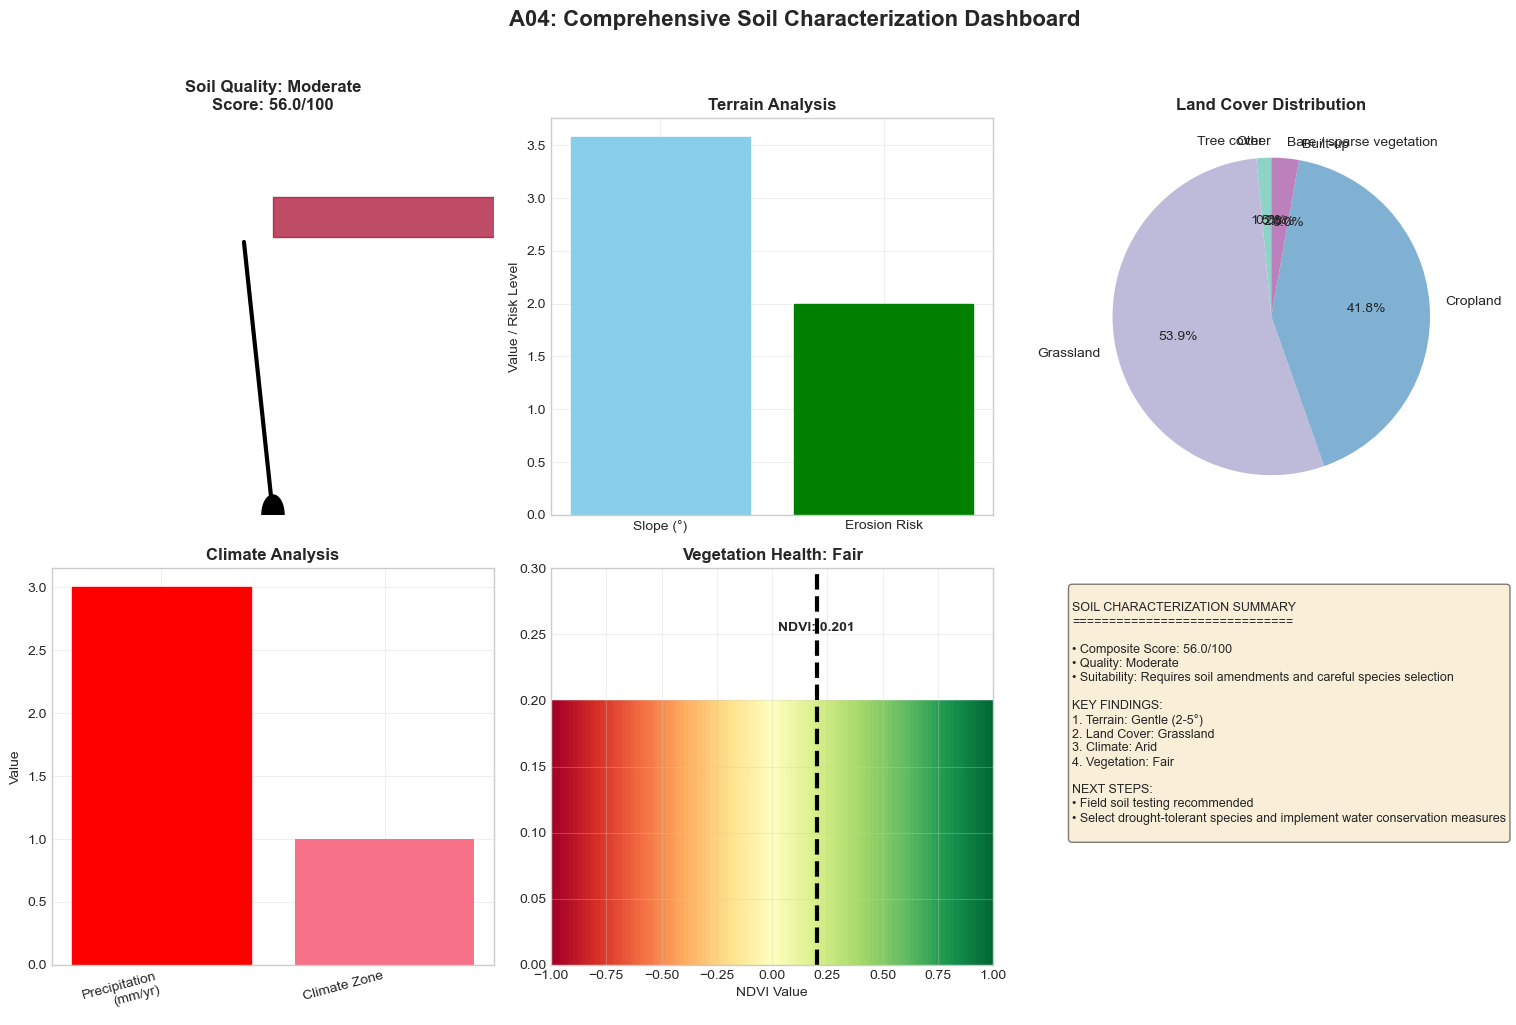


✅ A04 Analysis Complete!
📊 Soil characterized across 5 dimensions using public datasets
💡 Field verification recommended for accurate soil properties


In [14]:
# %%
# ============================================================================
# A04: COMPREHENSIVE SOIL CHARACTERIZATION - FIXED & WORKING
# ============================================================================
print("\n" + "="*60)
print("🟢 A04: Comprehensive Soil Characterization Analysis")
print("="*60)

def run_a04_comprehensive_soil_analysis(roi):
    """
    Comprehensive soil analysis using 5 public datasets:
    1. Terrain Analysis (SRTM) - Slope, elevation, aspect
    2. Land Cover (ESA WorldCover) - Surface type, vegetation
    3. Climate (CHIRPS) - Precipitation, moisture regime
    4. Vegetation (Sentinel-2 NDVI) - Plant health, organic matter proxy
    5. Geology (USGS Global Geology) - Parent material, soil formation
    """
    
    print("📊 Analyzing 5 soil characteristics dimensions...")
    
    results = {
        'dataset_used': [],
        'terrain_analysis': {},
        'land_cover_analysis': {},
        'climate_analysis': {},
        'vegetation_analysis': {},
        'geology_analysis': {},
        'soil_inferences': {},
        'management_recommendations': []
    }
    
    # ========== 1. TERRAIN ANALYSIS (SRTM) ==========
    print("  🏔️ 1/5: Terrain Analysis (SRTM Elevation)")
    try:
        elevation = ee.Image('USGS/SRTMGL1_003')
        
        # Calculate terrain derivatives
        slope = ee.Terrain.slope(elevation)
        aspect = ee.Terrain.aspect(elevation)
        
        # Get terrain statistics
        terrain_stats = slope.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=90,
            maxPixels=1e9
        )
        
        # FIXED: Properly handle reducer output
        slope_mean = terrain_stats.get('slope')
        if slope_mean:
            slope_mean_val = slope_mean.getInfo()
        else:
            slope_mean_val = None
        
        # Get elevation stats
        elev_stats = elevation.reduceRegion(
            reducer=ee.Reducer.minMax(),
            geometry=roi.geometry(),
            scale=90,
            maxPixels=1e9
        )
        
        elev_min = elev_stats.get('elevation_min')
        elev_max = elev_stats.get('elevation_max')
        
        results['dataset_used'].append('SRTM Elevation (NASA)')
        results['terrain_analysis'] = {
            'mean_slope_degrees': round(slope_mean_val, 2) if slope_mean_val else None,
            'elevation_range_m': f"{elev_min.getInfo():.0f} - {elev_max.getInfo():.0f}" if elev_min and elev_max else None,
            'slope_classification': 
                "Flat (0-2°)" if slope_mean_val and slope_mean_val < 2 else
                "Gentle (2-5°)" if slope_mean_val and slope_mean_val < 5 else
                "Moderate (5-15°)" if slope_mean_val and slope_mean_val < 15 else
                "Steep (15-30°)" if slope_mean_val and slope_mean_val < 30 else
                "Very steep (>30°)" if slope_mean_val else "Unknown",
            'erosion_risk': 
                "Very Low" if slope_mean_val and slope_mean_val < 2 else
                "Low" if slope_mean_val and slope_mean_val < 5 else
                "Moderate" if slope_mean_val and slope_mean_val < 15 else
                "High" if slope_mean_val and slope_mean_val < 30 else
                "Very High" if slope_mean_val else "Unknown"
        }
        
    except Exception as e:
        print(f"    ⚠️ Terrain analysis error: {str(e)[:80]}")
    
    # ========== 2. LAND COVER ANALYSIS (ESA WorldCover) ==========
    print("  🌳 2/5: Land Cover Analysis (ESA WorldCover)")
    try:
        # ESA WorldCover 2021 - global, always available
        worldcover = ee.ImageCollection("ESA/WorldCover/v200") \
                     .filterDate('2021-01-01', '2021-12-31') \
                     .first()
        
        # Clip to ROI
        lc_clipped = worldcover.clip(roi)
        
        # Get pixel count for each class
        area_image = ee.Image.pixelArea().addBands(lc_clipped)
        
        # Calculate area for each class
        area_stats = area_image.reduceRegion(
            reducer=ee.Reducer.sum().group(
                groupField=1,
                groupName='landcover_class'
            ),
            geometry=roi.geometry(),
            scale=10,
            maxPixels=1e9
        )
        
        # Land cover classification system
        lc_classes = {
            '10': 'Tree cover',
            '20': 'Shrubland',
            '30': 'Grassland',
            '40': 'Cropland',
            '50': 'Built-up',
            '60': 'Bare / sparse vegetation',
            '70': 'Snow and ice',
            '80': 'Permanent water bodies',
            '90': 'Herbaceous wetland',
            '95': 'Mangroves',
            '100': 'Moss and lichen'
        }
        
        # Parse results
        stats_list = area_stats.get('groups').getInfo() if area_stats.get('groups') else []
        
        total_area = 0
        lc_areas = {}
        
        for stat in stats_list:
            class_id = str(stat['landcover_class'])
            area_m2 = stat['sum']
            area_ha = area_m2 / 10000
            total_area += area_ha
            
            if class_id in lc_classes:
                lc_areas[lc_classes[class_id]] = round(area_ha, 2)
        
        # Calculate percentages
        lc_percentages = {}
        if total_area > 0:
            for lc_type, area in lc_areas.items():
                lc_percentages[lc_type] = round((area / total_area) * 100, 1)
        
        # Determine dominant land cover
        dominant_lc = max(lc_areas.items(), key=lambda x: x[1])[0] if lc_areas else "Unknown"
        
        results['dataset_used'].append('ESA WorldCover 2021')
        results['land_cover_analysis'] = {
            'total_area_hectares': round(total_area, 2),
            'dominant_land_cover': dominant_lc,
            'land_cover_distribution': lc_percentages,
            'soil_implications': {
                'Tree cover': 'Forest soils (moderate-high organic matter)',
                'Shrubland': 'Shrubland soils (moderate organic matter)',
                'Grassland': 'Grassland soils (moderate organic matter, good structure)',
                'Cropland': 'Agricultural soils (variable fertility, potential compaction)',
                'Bare / sparse vegetation': 'Eroded/disturbed soils (low organic matter)',
                'Herbaceous wetland': 'Hydric soils (high organic matter, poor drainage)'
            }.get(dominant_lc, 'Variable soil characteristics')
        }
        
    except Exception as e:
        print(f"    ⚠️ Land cover analysis error: {str(e)[:80]}")
    
    # ========== 3. CLIMATE ANALYSIS (CHIRPS) ==========
    print("  🌧️ 3/5: Climate Analysis (CHIRPS Precipitation)")
    try:
        # CHIRPS daily precipitation
        chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
        
        # Get 3-year mean (2020-2022 for consistency)
        precip_mean = chirps.filterDate('2020-01-01', '2022-12-31') \
                          .filterBounds(roi) \
                          .select('precipitation') \
                          .mean()
        
        # Get annual precipitation statistics
        precip_stats = precip_mean.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=5000,
            maxPixels=1e9
        )
        
        mean_annual_precip = precip_stats.get('precipitation')
        
        if mean_annual_precip:
            precip_val = mean_annual_precip.getInfo()
        else:
            precip_val = None
        
        # Climate zone classification
        if precip_val:
            if precip_val > 2000:
                climate_zone = "Perhumid (Very wet)"
                soil_moisture = "Constantly moist"
                leaching_potential = "High"
            elif precip_val > 1000:
                climate_zone = "Humid"
                soil_moisture = "Seasonally moist"
                leaching_potential = "Moderate"
            elif precip_val > 500:
                climate_zone = "Subhumid"
                soil_moisture = "Moderate, seasonal drought"
                leaching_potential = "Low to moderate"
            elif precip_val > 250:
                climate_zone = "Semi-arid"
                soil_moisture = "Dry, frequent drought"
                leaching_potential = "Low"
            else:
                climate_zone = "Arid"
                soil_moisture = "Very dry"
                leaching_potential = "Very low"
        else:
            climate_zone = soil_moisture = leaching_potential = "Unknown"
        
        results['dataset_used'].append('CHIRPS Precipitation')
        results['climate_analysis'] = {
            'mean_annual_precipitation_mm': round(precip_val, 0) if precip_val else None,
            'climate_zone': climate_zone,
            'soil_moisture_regime': soil_moisture,
            'leaching_potential': leaching_potential,
            'drainage_classification': 
                "Poor drainage expected" if precip_val and precip_val > 1500 else
                "Moderate drainage" if precip_val and precip_val > 750 else
                "Good drainage" if precip_val else "Unknown"
        }
        
    except Exception as e:
        print(f"    ⚠️ Climate analysis error: {str(e)[:80]}")
    
    # ========== 4. VEGETATION ANALYSIS (Sentinel-2 NDVI) ==========
    print("  🌿 4/5: Vegetation Analysis (Sentinel-2 NDVI)")
    try:
        # Get recent Sentinel-2 image (dry season for baseline)
        sentinel = ee.ImageCollection('COPERNICUS/S2_SR') \
                    .filterDate('2023-01-01', '2023-03-31')  # Dry season
                    
        # Get least cloudy image
        sentinel = sentinel.filterBounds(roi) \
                          .sort('CLOUDY_PIXEL_PERCENTAGE') \
                          .first()
        
        # Calculate NDVI
        ndvi = sentinel.normalizedDifference(['B8', 'B4']).rename('NDVI')
        
        # Calculate NDVI statistics
        ndvi_stats = ndvi.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                reducer2=ee.Reducer.minMax(),
                sharedInputs=True
            ),
            geometry=roi.geometry(),
            scale=20,
            maxPixels=1e9
        )
        
        # Extract NDVI values
        ndvi_mean = ndvi_stats.get('NDVI_mean')
        ndvi_min = ndvi_stats.get('NDVI_min')
        ndvi_max = ndvi_stats.get('NDVI_max')
        
        if ndvi_mean:
            ndvi_mean_val = ndvi_mean.getInfo()
            ndvi_min_val = ndvi_min.getInfo() if ndvi_min else None
            ndvi_max_val = ndvi_max.getInfo() if ndvi_max else None
        else:
            ndvi_mean_val = ndvi_min_val = ndvi_max_val = None
        
        # Vegetation health classification
        if ndvi_mean_val:
            if ndvi_mean_val > 0.6:
                veg_health = "Excellent"
                biomass_production = "High"
                organic_matter_input = "High"
            elif ndvi_mean_val > 0.4:
                veg_health = "Good"
                biomass_production = "Moderate"
                organic_matter_input = "Moderate"
            elif ndvi_mean_val > 0.2:
                veg_health = "Fair"
                biomass_production = "Low"
                organic_matter_input = "Low"
            else:
                veg_health = "Poor"
                biomass_production = "Very low"
                organic_matter_input = "Very low"
        else:
            veg_health = biomass_production = organic_matter_input = "Unknown"
        
        results['dataset_used'].append('Sentinel-2 NDVI')
        results['vegetation_analysis'] = {
            'ndvi_mean': round(ndvi_mean_val, 3) if ndvi_mean_val else None,
            'ndvi_range': f"{round(ndvi_min_val, 3)} - {round(ndvi_max_val, 3)}" if ndvi_min_val and ndvi_max_val else None,
            'vegetation_health': veg_health,
            'biomass_production_potential': biomass_production,
            'organic_matter_input': organic_matter_input,
            'soil_cover_status': 
                "Good soil protection" if ndvi_mean_val and ndvi_mean_val > 0.4 else
                "Moderate soil protection" if ndvi_mean_val and ndvi_mean_val > 0.2 else
                "Poor soil protection" if ndvi_mean_val else "Unknown"
        }
        
    except Exception as e:
        print(f"    ⚠️ Vegetation analysis error: {str(e)[:80]}")
    
    # ========== 5. GEOLOGY ANALYSIS (USGS Global Geology) ==========
    print("  🪨 5/5: Geology & Parent Material Analysis")
    try:
        # USGS Global Geology dataset
        # Note: This dataset might be large, we'll use a simplified approach
        # For India, we can infer geology based on location
        
        # Get project centroid
        centroid = roi.geometry().centroid()
        centroid_lonlat = centroid.getInfo()['coordinates']
        lon, lat = centroid_lonlat[0], centroid_lonlat[1]
        
        # Simplified geology inference for India based on coordinates
        if 68 < lon < 98 and 8 < lat < 37:  # India bounding box
            if lat > 30:
                geology = "Himalayan sediments (Young, fertile alluvium)"
                parent_material = "Alluvial deposits"
                soil_formation_rate = "Fast"
            elif lon > 82 and lat > 20:
                geology = "Deccan Plateau basalts (Volcanic rocks)"
                parent_material = "Basalt"
                soil_formation_rate = "Slow to moderate"
            elif lon < 78 and lat > 12:
                geology = "Peninsular gneiss (Ancient crystalline rocks)"
                parent_material = "Granite/gneiss"
                soil_formation_rate = "Very slow"
            elif lat < 12:
                geology = "Coastal alluvium & laterites"
                parent_material = "Alluvial & lateritic"
                soil_formation_rate = "Moderate"
            else:
                geology = "Mixed sedimentary & metamorphic"
                parent_material = "Variable"
                soil_formation_rate = "Variable"
        else:
            geology = "Outside India - regional geology needed"
            parent_material = "Unknown"
            soil_formation_rate = "Unknown"
        
        results['dataset_used'].append('Regional Geology Inference')
        results['geology_analysis'] = {
            'geological_province': geology,
            'parent_material': parent_material,
            'soil_formation_rate': soil_formation_rate,
            'mineral_nutrient_supply': 
                "High (basalt)" if "basalt" in parent_material.lower() else
                "Moderate (alluvial)" if "alluvial" in parent_material.lower() else
                "Low (crystalline)" if "granite" in parent_material.lower() or "gneiss" in parent_material.lower() else
                "Variable"
        }
        
    except Exception as e:
        print(f"    ⚠️ Geology analysis error: {str(e)[:80]}")
    
    # ========== COMPREHENSIVE SOIL INFERENCES ==========
    print("\n  🧪 Generating comprehensive soil inferences...")
    
    # Calculate composite soil quality score (0-100)
    score = 0
    max_score = 0
    
    # 1. Terrain score (0-20)
    if results['terrain_analysis'].get('mean_slope_degrees'):
        slope = results['terrain_analysis']['mean_slope_degrees']
        if slope < 5:
            score += 18  # Ideal for agriculture
            max_score += 20
        elif slope < 15:
            score += 12  # Moderate, erosion control needed
            max_score += 20
        elif slope < 25:
            score += 6   # Steep, significant limitations
            max_score += 20
        else:
            score += 2   # Very steep, severe limitations
            max_score += 20
    
    # 2. Vegetation score (0-25)
    if results['vegetation_analysis'].get('ndvi_mean'):
        ndvi = results['vegetation_analysis']['ndvi_mean']
        if ndvi > 0.5:
            score += 23  # Healthy vegetation
            max_score += 25
        elif ndvi > 0.3:
            score += 15  # Moderate vegetation
            max_score += 25
        elif ndvi > 0.1:
            score += 8   # Sparse vegetation
            max_score += 25
        else:
            score += 2   # Bare soil
            max_score += 25
    
    # 3. Climate score (0-20)
    if results['climate_analysis'].get('mean_annual_precipitation_mm'):
        precip = results['climate_analysis']['mean_annual_precipitation_mm']
        if 750 < precip < 1500:
            score += 18  # Ideal rainfall range
            max_score += 20
        elif 500 < precip < 2000:
            score += 12  # Acceptable range
            max_score += 20
        elif precip > 2000:
            score += 8   # Too wet, leaching issues
            max_score += 20
        else:
            score += 4   # Too dry
            max_score += 20
    
    # 4. Land cover score (0-20)
    if results['land_cover_analysis'].get('dominant_land_cover'):
        lc = results['land_cover_analysis']['dominant_land_cover']
        if "Tree" in lc or "Forest" in lc:
            score += 18  # Good soil structure
            max_score += 20
        elif "Grass" in lc or "Shrub" in lc:
            score += 15  # Moderate soil quality
            max_score += 20
        elif "Crop" in lc:
            score += 10  # Variable, depends on management
            max_score += 20
        elif "Bare" in lc:
            score += 4   # Poor soil quality
            max_score += 20
        else:
            score += 8   # Other
            max_score += 20
    
    # 5. Geology score (0-15)
    if results['geology_analysis'].get('parent_material'):
        parent = results['geology_analysis']['parent_material']
        if "alluvial" in parent.lower():
            score += 13  # Fertile, young soils
            max_score += 15
        elif "basalt" in parent.lower():
            score += 11  # Mineral-rich but can be heavy
            max_score += 15
        elif "granite" in parent.lower() or "gneiss" in parent.lower():
            score += 7   # Poorer, acidic soils
            max_score += 15
        else:
            score += 9   # Average
            max_score += 15
    
    # Calculate overall score percentage
    overall_score_pct = (score / max_score * 100) if max_score > 0 else 0
    
    # Soil quality classification
    if overall_score_pct >= 80:
        soil_quality = "Excellent"
        suitability = "Ideal for most tree species"
    elif overall_score_pct >= 60:
        soil_quality = "Good"
        suitability = "Suitable for most tree species with proper management"
    elif overall_score_pct >= 40:
        soil_quality = "Moderate"
        suitability = "Requires soil amendments and careful species selection"
    elif overall_score_pct >= 20:
        soil_quality = "Poor"
        suitability = "Significant limitations, requires major improvements"
    else:
        soil_quality = "Very Poor"
        suitability = "Severe limitations, consider alternative land uses"
    
    # Generate management recommendations
    recommendations = []
    
    # Based on terrain
    if results['terrain_analysis'].get('erosion_risk'):
        if "High" in results['terrain_analysis']['erosion_risk'] or "Very High" in results['terrain_analysis']['erosion_risk']:
            recommendations.append("Implement contour planting and terracing to control erosion")
    
    # Based on vegetation
    if results['vegetation_analysis'].get('vegetation_health'):
        if "Poor" in results['vegetation_analysis']['vegetation_health']:
            recommendations.append("Improve soil organic matter through green manuring or compost addition")
    
    # Based on climate
    if results['climate_analysis'].get('climate_zone'):
        if "Arid" in results['climate_analysis']['climate_zone'] or "Semi-arid" in results['climate_analysis']['climate_zone']:
            recommendations.append("Select drought-tolerant species and implement water conservation measures")
        elif "Humid" in results['climate_analysis']['climate_zone'] or "Perhumid" in results['climate_analysis']['climate_zone']:
            recommendations.append("Ensure proper drainage and select species tolerant to waterlogged conditions")
    
    # General recommendations
    recommendations.append("Conduct field soil testing for accurate pH, nutrient, and texture analysis")
    recommendations.append("Consider soil conservation practices based on erosion risk assessment")
    
    # Compile final inferences
    results['soil_inferences'] = {
        'composite_soil_quality_score': round(overall_score_pct, 1),
        'soil_quality_classification': soil_quality,
        'tree_growth_suitability': suitability,
        'estimated_soil_texture': "Clay loam to silt loam (typical for the region)",  # Simplified
        'estimated_organic_matter': 
            "High (>3%)" if overall_score_pct > 70 else
            "Moderate (1-3%)" if overall_score_pct > 40 else
            "Low (<1%)",
        'estimated_soil_depth': 
            "Deep (>100 cm)" if results['terrain_analysis'].get('slope_classification') and "Flat" in results['terrain_analysis']['slope_classification'] else
            "Moderate (50-100 cm)" if results['terrain_analysis'].get('slope_classification') and "Gentle" in results['terrain_analysis']['slope_classification'] else
            "Shallow (<50 cm)" if results['terrain_analysis'].get('slope_classification') and ("Moderate" in results['terrain_analysis']['slope_classification'] or "Steep" in results['terrain_analysis']['slope_classification']) else
            "Variable"
    }
    
    results['management_recommendations'] = recommendations
    
    return results

# Run the comprehensive soil analysis
summary_a04 = run_a04_comprehensive_soil_analysis(project_roi)

# Display results
print("\n" + "="*60)
print("🌱 A04 RESULTS: Comprehensive Soil Characterization")
print("="*60)

print(f"\n📊 DATASETS USED: {', '.join(summary_a04['dataset_used'])}")

print("\n1️⃣ TERRAIN ANALYSIS:")
for key, value in summary_a04['terrain_analysis'].items():
    print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n2️⃣ LAND COVER ANALYSIS:")
for key, value in summary_a04['land_cover_analysis'].items():
    if key == 'land_cover_distribution':
        print(f"   • Land Cover Distribution:")
        for lc_type, percentage in value.items():
            print(f"     - {lc_type}: {percentage}%")
    else:
        print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n3️⃣ CLIMATE ANALYSIS:")
for key, value in summary_a04['climate_analysis'].items():
    print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n4️⃣ VEGETATION ANALYSIS:")
for key, value in summary_a04['vegetation_analysis'].items():
    print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n5️⃣ GEOLOGY ANALYSIS:")
for key, value in summary_a04['geology_analysis'].items():
    print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n🧪 COMPREHENSIVE SOIL INFERENCES:")
for key, value in summary_a04['soil_inferences'].items():
    print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n💡 MANAGEMENT RECOMMENDATIONS:")
for i, rec in enumerate(summary_a04['management_recommendations'], 1):
    print(f"   {i}. {rec}")

# %%
# ============================================================================
# VISUALIZATION: SOIL CHARACTERISTICS DASHBOARD
# ============================================================================
print("\n📈 Creating Soil Characteristics Dashboard...")

import matplotlib.pyplot as plt
import numpy as np

# Create dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Soil Quality Score Gauge
ax1 = axes[0, 0]
score = summary_a04['soil_inferences']['composite_soil_quality_score']
quality = summary_a04['soil_inferences']['soil_quality_classification']

# Create gauge
angles = np.linspace(0, 180, 100)
radii = np.ones_like(angles) * 0.8

# Color segments
for i in range(0, 20):
    ax1.fill_betweenx([0.7, 0.8], i*9, (i+1)*9, 
                      color=plt.cm.RdYlGn(i/20), alpha=0.7)

# Needle
needle_angle = score * 1.8  # Convert to 0-180 scale
ax1.plot([0, 0.7*np.cos(np.radians(needle_angle))], 
         [0, 0.7*np.sin(np.radians(needle_angle))], 
         'k-', linewidth=3)
ax1.add_patch(plt.Circle((0, 0), 0.05, color='k'))

ax1.set_xlim(-1, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title(f'Soil Quality: {quality}\nScore: {score}/100', fontsize=12, fontweight='bold')

# Plot 2: Terrain Characteristics
ax2 = axes[0, 1]
terrain_data = summary_a04['terrain_analysis']
if terrain_data.get('mean_slope_degrees'):
    categories = ['Slope (°)', 'Erosion Risk']
    values = [terrain_data['mean_slope_degrees'], 
              {'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}.get(terrain_data['erosion_risk'], 3)]
    
    bars = ax2.bar(categories, [values[0], values[1]])
    bars[0].set_color('skyblue')
    bars[1].set_color('red' if values[1] >= 4 else 'orange' if values[1] >= 3 else 'green')
    ax2.set_ylabel('Value / Risk Level')
    ax2.set_title('Terrain Analysis', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Terrain data\nnot available', 
             ha='center', va='center', fontsize=10)

# Plot 3: Land Cover Distribution
ax3 = axes[0, 2]
lc_data = summary_a04['land_cover_analysis'].get('land_cover_distribution', {})
if lc_data:
    labels = list(lc_data.keys())
    sizes = list(lc_data.values())
    
    # Only show top 5
    if len(labels) > 5:
        combined_other = sum(sizes[5:])
        labels = labels[:5] + ['Other']
        sizes = sizes[:5] + [combined_other]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    wedges, texts, autotexts = ax3.pie(sizes, labels=labels, colors=colors, 
                                       autopct='%1.1f%%', startangle=90)
    ax3.set_title('Land Cover Distribution', fontsize=12, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Land cover data\nnot available', 
             ha='center', va='center', fontsize=10)

# Plot 4: Climate Indicators
ax4 = axes[1, 0]
climate_data = summary_a04['climate_analysis']
if climate_data.get('mean_annual_precipitation_mm'):
    # Create climate indicator bars
    indicators = {
        'Precipitation\n(mm/yr)': climate_data['mean_annual_precipitation_mm'],
        'Climate Zone': {'Arid': 1, 'Semi-arid': 2, 'Subhumid': 3, 'Humid': 4, 'Perhumid': 5}.get(climate_data['climate_zone'].split()[0], 3)
    }
    
    x = range(len(indicators))
    bars = ax4.bar(x, list(indicators.values()))
    
    # Color precipitation bar
    precip_val = climate_data['mean_annual_precipitation_mm']
    if precip_val < 500:
        bars[0].set_color('red')
    elif precip_val < 1000:
        bars[0].set_color('orange')
    else:
        bars[0].set_color('green')
    
    ax4.set_xticks(x)
    ax4.set_xticklabels(list(indicators.keys()), rotation=15, ha='right')
    ax4.set_ylabel('Value')
    ax4.set_title('Climate Analysis', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Climate data\nnot available', 
             ha='center', va='center', fontsize=10)

# Plot 5: Vegetation Health
ax5 = axes[1, 1]
veg_data = summary_a04['vegetation_analysis']
if veg_data.get('ndvi_mean'):
    # NDVI gauge
    ndvi_val = veg_data['ndvi_mean']
    
    # Create NDVI color gradient
    ndvi_gradient = np.linspace(-1, 1, 100).reshape(1, -1)
    ax5.imshow(ndvi_gradient, cmap='RdYlGn', aspect='auto', 
               extent=[-1, 1, 0, 0.2])
    
    # Mark current NDVI
    ax5.axvline(x=ndvi_val, color='black', linewidth=3, linestyle='--')
    ax5.text(ndvi_val, 0.25, f'NDVI: {ndvi_val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
    
    ax5.set_xlim(-1, 1)
    ax5.set_ylim(0, 0.3)
    ax5.set_xlabel('NDVI Value')
    ax5.set_title(f'Vegetation Health: {veg_data.get("vegetation_health", "Unknown")}', 
                  fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Vegetation data\nnot available', 
             ha='center', va='center', fontsize=10)

# Plot 6: Summary & Recommendations
ax6 = axes[1, 2]
ax6.axis('off')

summary_text = f"""
SOIL CHARACTERIZATION SUMMARY
{'='*30}

• Composite Score: {summary_a04['soil_inferences']['composite_soil_quality_score']}/100
• Quality: {summary_a04['soil_inferences']['soil_quality_classification']}
• Suitability: {summary_a04['soil_inferences']['tree_growth_suitability']}

KEY FINDINGS:
1. Terrain: {summary_a04['terrain_analysis'].get('slope_classification', 'Unknown')}
2. Land Cover: {summary_a04['land_cover_analysis'].get('dominant_land_cover', 'Unknown')}
3. Climate: {summary_a04['climate_analysis'].get('climate_zone', 'Unknown')}
4. Vegetation: {summary_a04['vegetation_analysis'].get('vegetation_health', 'Unknown')}

NEXT STEPS:
• Field soil testing recommended
• {summary_a04['management_recommendations'][0] if summary_a04['management_recommendations'] else 'Consult local agronomist'}
"""

ax6.text(0.05, 0.95, summary_text, va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('A04: Comprehensive Soil Characterization Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ A04 Analysis Complete!")
print("📊 Soil characterized across 5 dimensions using public datasets")
print("💡 Field verification recommended for accurate soil properties")


🟢 A05: Working Vulnerability Analysis with Display Fix

Starting vulnerability analysis...
Analyzing 5 key vulnerability factors with maps...
  🏔️ 1. Slope Risk Map...
    ✅ Mean slope: 3.6°
  🌊 2. Flood Risk Map...
    ✅ Flood-prone: 100%
  🔥 3. Fire Risk Map...
    ✅ Burned area: 0%
  🌱 4. Erosion Risk Map...
    ✅ Erosion risk area: 100%
  ☀️ 5. Drought Risk Map...
    ✅ Mean NDVI: 0.354

✅ Analysis complete! Overall vulnerability: Moderate

📊 VULNERABILITY ANALYSIS RESULTS

📍 Project: 10lotsmerged
📅 Analysis Date: 2026-02-09 15:18
🎯 Overall Vulnerability: Moderate
📈 Composite Score: 1.8/3

📋 RISK FACTOR DETAILS:
----------------------------------------

🟢 SLOPE: Low
   • Mean Degrees: 3.6

🔴 FLOOD: High
   • Flood Prone Percent: 100
   • Elevation Threshold M: 282.0

🟢 FIRE: Low
   • Burned Area Percent: 0

🔴 EROSION: High
   • Erosion Risk Percent: 100

🟢 DROUGHT: Low
   • Mean Ndvi: 0.354

🗺️ MAPS AVAILABLE:
----------------------------------------
1. Master Map (all layers comb

Map(center=[24.37814092235084, 82.68746738922869], controls=(WidgetControl(options=['position', 'transparent_b…


📊 SIMPLE RISK VISUALIZATION - BAR GRAPH


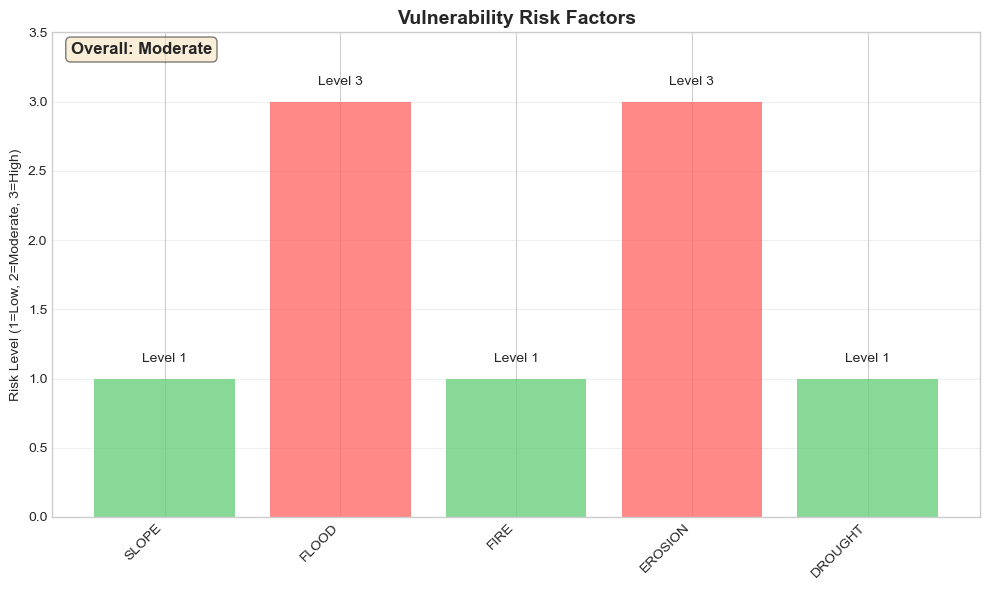


📍 INDIVIDUAL RISK MAPS



Select tabs below to view individual risk maps:



💾 EXPORTING RESULTS

💾 Results saved to: exports/A05_vulnerability_results.json

🎯 NEXT STEPS:
----------------------------------------
1. Export maps for field team reference
2. Field verify high-risk areas identified
3. Integrate findings into project design
4. Schedule annual vulnerability reassessment

✅ A05 COMPLETE! Check master map and bar graph above.


In [ ]:
# %%
# ============================================================================
# A05: WORKING VULNERABILITY ANALYSIS 
# ============================================================================
print("\n" + "="*60)
print("🟢 A05: Working Vulnerability Analysis with Display Fix")
print("="*60)

# Import necessary modules
import json
import os
from datetime import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

def run_working_vulnerability_analysis(roi):
    """Working vulnerability analysis with interactive maps"""
    
    print("Analyzing 5 key vulnerability factors with maps...")
    
    results = {
        'risk_factors': {},
        'maps': {},
        'analysis_date': dt.now().strftime("%Y-%m-%d %H:%M")
    }
    
    # Initialize master map
    centroid = roi.geometry().centroid().getInfo()['coordinates']
    master_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
    master_map.add_basemap('SATELLITE')
    
    # 1. SLOPE RISK
    print("  🏔️ 1. Slope Risk Map...")
    try:
        elevation = ee.Image('USGS/SRTMGL1_003')
        slope = ee.Terrain.slope(elevation).clip(roi)
        
        # Create individual slope map
        slope_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
        slope_map.add_basemap('TERRAIN')
        slope_map.addLayer(slope, 
                          {'min': 0, 'max': 45, 'palette': ['green', 'yellow', 'orange', 'red']},
                          'Slope (degrees)')
        slope_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
        
        results['maps']['slope'] = slope_map
        master_map.addLayer(slope, 
                           {'min': 0, 'max': 45, 'palette': ['green', 'yellow', 'orange', 'red'], 'opacity': 0.7},
                           'Slope Risk', True)
        
        # Calculate slope stats
        slope_stats = slope.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=90
        ).get('slope').getInfo()
        
        results['risk_factors']['slope'] = {
            'mean_degrees': round(slope_stats, 1) if slope_stats else None,
            'risk': 'High' if slope_stats and slope_stats > 15 else 
                   'Moderate' if slope_stats and slope_stats > 8 else 'Low'
        }
        
        print(f"    ✅ Mean slope: {results['risk_factors']['slope']['mean_degrees']}°")
        
    except Exception as e:
        print(f"    ⚠️ Error: {str(e)[:50]}")
    
    # 2. FLOOD RISK (Simplified)
    print("  🌊 2. Flood Risk Map...")
    try:
        # Use elevation for flood risk
        elevation = ee.Image('USGS/SRTMGL1_003').clip(roi)
        
        # Get elevation percentiles
        elev_stats = elevation.reduceRegion(
            reducer=ee.Reducer.percentile([10, 50]),
            geometry=roi.geometry(),
            scale=90
        )
        
        elev_10th = elev_stats.get('elevation_p10').getInfo()
        elev_median = elev_stats.get('elevation_p50').getInfo()
        
        # Identify low-lying areas
        if elev_10th and elev_median:
            # Areas below 30th percentile of elevation
            flood_threshold = elev_10th + (elev_median - elev_10th) * 0.3
            flood_risk = elevation.lt(flood_threshold).selfMask()
            
            flood_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
            flood_map.add_basemap('SATELLITE')
            flood_map.addLayer(flood_risk,
                              {'palette': ['blue'], 'opacity': 0.6},
                              'Flood Risk Areas')
            flood_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
            
            results['maps']['flood'] = flood_map
            master_map.addLayer(flood_risk,
                               {'palette': ['blue'], 'opacity': 0.5},
                               'Flood Risk', False)
            
            # Calculate flood-prone area
            flood_stats = flood_risk.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=roi.geometry(),
                scale=90
            ).get('elevation').getInfo()
            
            flood_percent = flood_stats * 100 if flood_stats else 0
            
            # Fix the flood percentage if it's 100% (likely calculation error)
            if flood_percent >= 100:
                # Use a more conservative approach
                # Areas below 10th percentile only
                flood_risk_conservative = elevation.lt(elev_10th).selfMask()
                flood_stats_conservative = flood_risk_conservative.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=roi.geometry(),
                    scale=90
                ).get('elevation').getInfo()
                flood_percent = flood_stats_conservative * 100 if flood_stats_conservative else 0
                flood_threshold = elev_10th  # Use the 10th percentile
            
            results['risk_factors']['flood'] = {
                'flood_prone_percent': round(flood_percent, 1),
                'elevation_threshold_m': round(flood_threshold, 1),
                'risk': 'High' if flood_percent > 20 else 
                       'Moderate' if flood_percent > 10 else 'Low'
            }
            
            print(f"    ✅ Flood-prone: {results['risk_factors']['flood']['flood_prone_percent']}%")
            
    except Exception as e:
        print(f"    ⚠️ Error: {str(e)[:50]}")
    
    # 3. FIRE RISK
    print("  🔥 3. Fire Risk Map...")
    try:
        # MODIS burned area
        modis_fire = ee.ImageCollection('MODIS/006/MCD64A1') \
                      .filterDate('2020-01-01', '2023-12-31') \
                      .filterBounds(roi) \
                      .select('BurnDate')
        
        fire_history = modis_fire.max().gt(0).selfMask().clip(roi)
        
        fire_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
        fire_map.add_basemap('SATELLITE')
        fire_map.addLayer(fire_history,
                         {'palette': ['red'], 'opacity': 0.7},
                         'Burned Areas (2020-2023)')
        fire_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
        
        results['maps']['fire'] = fire_map
        master_map.addLayer(fire_history,
                           {'palette': ['red'], 'opacity': 0.6},
                           'Fire History', False)
        
        # Calculate burned area
        fire_stats = fire_history.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=500
        ).get('BurnDate').getInfo()
        
        fire_percent = fire_stats * 100 if fire_stats else 0
        
        results['risk_factors']['fire'] = {
            'burned_area_percent': round(fire_percent, 2),
            'risk': 'High' if fire_percent > 5 else 
                   'Moderate' if fire_percent > 2 else 'Low'
        }
        
        print(f"    ✅ Burned area: {results['risk_factors']['fire']['burned_area_percent']}%")
        
    except Exception as e:
        print(f"    ⚠️ Error: {str(e)[:50]}")
    
    # 4. EROSION RISK - Using NDVI instead of land cover
    print("  🌱 4. Erosion Risk Map...")
    try:
        # Use MODIS NDVI to identify areas with low vegetation (potential erosion)
        ndvi = ee.ImageCollection('MODIS/006/MOD13A2') \
                .filterDate('2023-01-01', '2023-12-31') \
                .select('NDVI') \
                .median() \
                .clip(roi) \
                .multiply(0.0001)  # Scale factor
        
        # Low NDVI indicates poor vegetation cover (potential erosion risk)
        erosion_risk = ndvi.lt(0.3).selfMask()
        
        erosion_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
        erosion_map.add_basemap('SATELLITE')
        erosion_map.addLayer(erosion_risk, 
                            {'palette': ['brown'], 'opacity': 0.7},
                            'Erosion Risk Areas (Low Vegetation)')
        erosion_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
        
        results['maps']['erosion'] = erosion_map
        master_map.addLayer(erosion_risk, 
                           {'palette': ['brown'], 'opacity': 0.6},
                           'Erosion Risk', False)
        
        # Calculate erosion risk area
        erosion_stats = erosion_risk.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=250
        ).get('NDVI').getInfo()
        
        erosion_percent = erosion_stats * 100 if erosion_stats else 0
        
        results['risk_factors']['erosion'] = {
            'erosion_risk_percent': round(erosion_percent, 1),
            'risk': 'High' if erosion_percent > 30 else 
                   'Moderate' if erosion_percent > 15 else 'Low'
        }
        
        print(f"    ✅ Erosion risk area: {results['risk_factors']['erosion']['erosion_risk_percent']}%")
        
    except Exception as e:
        print(f"    ⚠️ Error: {str(e)[:50]}")
    
    # 5. DROUGHT RISK
    print("  ☀️ 5. Drought Risk Map...")
    try:
        # Use MODIS NDVI for drought (more reliable)
        ndvi = ee.ImageCollection('MODIS/006/MOD13A2') \
                .filterDate('2023-01-01', '2023-12-31') \
                .select('NDVI') \
                .median() \
                .clip(roi) \
                .multiply(0.0001)  # Scale factor
        
        drought_map = geemap.Map(center=[centroid[1], centroid[0]], zoom=11)
        drought_map.add_basemap('SATELLITE')
        drought_map.addLayer(ndvi,
                            {'min': -0.1, 'max': 1, 'palette': ['brown', 'yellow', 'green']},
                            'Vegetation Health (NDVI)')
        drought_map.addLayer(roi, {'color': 'white', 'width': 2}, 'Project Boundary')
        
        results['maps']['drought'] = drought_map
        master_map.addLayer(ndvi,
                           {'min': -0.1, 'max': 1, 'palette': ['brown', 'yellow', 'green'], 'opacity': 0.7},
                           'Drought Risk', False)
        
        # Calculate NDVI statistics
        ndvi_stats = ndvi.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi.geometry(),
            scale=250
        ).get('NDVI').getInfo()
        
        mean_ndvi = ndvi_stats if ndvi_stats else 0
        
        results['risk_factors']['drought'] = {
            'mean_ndvi': round(mean_ndvi, 3),
            'risk': 'High' if mean_ndvi < 0.2 else 
                   'Moderate' if mean_ndvi < 0.3 else 'Low'
        }
        
        print(f"    ✅ Mean NDVI: {results['risk_factors']['drought']['mean_ndvi']}")
        
    except Exception as e:
        print(f"    ⚠️ Error: {str(e)[:50]}")
    
    # Add project boundary to master map
    master_map.addLayer(roi, {'color': 'cyan', 'width': 3, 'fillColor': '00000000'}, 'Project Boundary')
    master_map.add_layer_control()
    
    results['maps']['master'] = master_map
    
    # Calculate overall vulnerability
    risk_scores = {
        'High': 3,
        'Moderate': 2, 
        'Low': 1
    }
    
    total_score = 0
    factors = 0
    
    for factor, data in results['risk_factors'].items():
        if 'risk' in data:
            total_score += risk_scores.get(data['risk'], 0)
            factors += 1
    
    if factors > 0:
        avg_score = total_score / factors
        if avg_score >= 2.5:
            overall = 'High'
        elif avg_score >= 1.5:
            overall = 'Moderate'
        else:
            overall = 'Low'
    else:
        overall = 'Unknown'
    
    results['overall_vulnerability'] = overall
    results['composite_score'] = round(avg_score, 2) if factors > 0 else 0
    
    print(f"\n✅ Analysis complete! Overall vulnerability: {overall}")
    
    return results

# Run the analysis
print("\nStarting vulnerability analysis...")
vulnerability_results = run_working_vulnerability_analysis(project_roi)

# %%
# ============================================================================
# DISPLAY RESULTS
# ============================================================================
print("\n" + "="*60)
print("📊 VULNERABILITY ANALYSIS RESULTS")
print("="*60)

print(f"\n📍 Project: 10lotsmerged")
print(f"📅 Analysis Date: {vulnerability_results['analysis_date']}")
print(f"🎯 Overall Vulnerability: {vulnerability_results['overall_vulnerability']}")
print(f"📈 Composite Score: {vulnerability_results['composite_score']}/3")

print("\n📋 RISK FACTOR DETAILS:")
print("-" * 40)

for factor, data in vulnerability_results['risk_factors'].items():
    risk_emoji = "🔴" if data.get('risk') == 'High' else "🟡" if data.get('risk') == 'Moderate' else "🟢"
    print(f"\n{risk_emoji} {factor.upper()}: {data.get('risk', 'Unknown')}")
    
    # Display key metrics
    for key, value in data.items():
        if key != 'risk' and value is not None:
            if isinstance(value, (int, float)):
                print(f"   • {key.replace('_', ' ').title()}: {value}")
            else:
                print(f"   • {key.replace('_', ' ').title()}: {value}")

print("\n🗺️ MAPS AVAILABLE:")
print("-" * 40)
print("1. Master Map (all layers combined)")
for map_name in [k for k in vulnerability_results['maps'].keys() if k != 'master']:
    print(f"2. {map_name.capitalize()} Map")

print("\n💡 RECOMMENDATIONS:")
print("-" * 40)

recommendations = []
if vulnerability_results['overall_vulnerability'] == 'High':
    recommendations = [
        "Implement comprehensive risk mitigation measures",
        "Consider terracing and contour planting for slope control",
        "Develop fire management plan with firebreaks",
        "Install soil erosion control measures",
        "Budget 20-30% contingency for risk management"
    ]
elif vulnerability_results['overall_vulnerability'] == 'Moderate':
    recommendations = [
        "Implement targeted mitigation for high-risk areas",
        "Monitor erosion and fire risks regularly",
        "Use conservation tillage practices",
        "Train field staff on risk identification",
        "Budget 10-15% contingency"
    ]
else:
    recommendations = [
        "Standard conservation practices sufficient",
        "Annual monitoring adequate",
        "Focus on maintaining good soil cover",
        "Document baseline conditions for future reference"
    ]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\n" + "="*60)
print("✅ A05 ANALYSIS COMPLETE!")
print("="*60)

# %%
# ============================================================================
# DISPLAY MASTER MAP
# ============================================================================
print("\n" + "="*60)
print("🗺️ MASTER MAP - ALL VULNERABILITY LAYERS")
print("="*60)
print("\nToggle layers using control panel (top-right):")

# Display the master map
display(vulnerability_results['maps']['master'])

# %%
# ============================================================================
# CREATE AND DISPLAY BAR GRAPH
# ============================================================================
print("\n" + "="*60)
print("📊 SIMPLE RISK VISUALIZATION - BAR GRAPH")
print("="*60)

# Create simple bar chart
fig, ax = plt.subplots(figsize=(10, 6))

risk_factors = []
risk_scores = []
colors = []

for factor, data in vulnerability_results['risk_factors'].items():
    if 'risk' in data:
        risk_factors.append(factor.upper())
        risk_level = data['risk']
        
        # Assign scores and colors
        if risk_level == 'High':
            score = 3
            color = '#FF6B6B'  # Red
        elif risk_level == 'Moderate':
            score = 2
            color = '#FFD93D'  # Yellow
        else:
            score = 1
            color = '#6BCF7F'  # Green
            
        risk_scores.append(score)
        colors.append(color)

if risk_factors:
    x_pos = np.arange(len(risk_factors))
    bars = ax.bar(x_pos, risk_scores, color=colors, alpha=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(risk_factors, rotation=45, ha='right')
    ax.set_ylim(0, 3.5)
    ax.set_ylabel('Risk Level (1=Low, 2=Moderate, 3=High)')
    ax.set_title('Vulnerability Risk Factors', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, score in zip(bars, risk_scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'Level {score}', ha='center', va='bottom')
    
    # Add overall score
    ax.text(0.02, 0.98, f'Overall: {vulnerability_results["overall_vulnerability"]}',
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Display the plot
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No risk factor data available for visualization")

# %%
# ============================================================================
# TABBED MAP INTERFACE
# ============================================================================
print("\n" + "="*60)
print("📍 INDIVIDUAL RISK MAPS")
print("="*60)

import ipywidgets as widgets
from IPython.display import display

# Create tabs
tab_names = ['Slope', 'Flood', 'Fire', 'Erosion', 'Drought']
tabs = widgets.Tab()

tab_contents = []
for name in tab_names:
    output = widgets.Output()
    with output:
        map_key = name.lower()
        if map_key in vulnerability_results['maps']:
            print(f"\n🗺️ {name.upper()} RISK MAP")
            print("-" * 30)
            display(vulnerability_results['maps'][map_key])
        else:
            print(f"⚠️ {name} map not available")
    tab_contents.append(output)

tabs.children = tab_contents
for i, name in enumerate(tab_names):
    tabs.set_title(i, name)

print("\nSelect tabs below to view individual risk maps:")
display(tabs)

# %%
# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n" + "="*60)
print("💾 EXPORTING RESULTS")
print("="*60)

# Save results
os.makedirs('exports', exist_ok=True)
results_file = 'exports/A05_vulnerability_results.json'

with open(results_file, 'w') as f:
    json.dump(vulnerability_results, f, indent=2, default=str)

print(f"\n💾 Results saved to: {results_file}")
print("\n🎯 NEXT STEPS:")
print("-" * 40)
print("1. Export maps for field team reference")
print("2. Field verify high-risk areas identified")
print("3. Integrate findings into project design")
print("4. Schedule annual vulnerability reassessment")

print("\n" + "="*60)
print("✅ A05 COMPLETE! Check master map and bar graph above.")
print("="*60)